## Ordering of operations

[1] and [3] motivate a procedure when trying to simulate a progression of meltwater input to the system where we do $$F_d(m1) = w1$$ then feed $w1$ into the next call to $F_D$ in addition to the new melt input $m2$: $$F_d(w1 + m2) = w2$$. 

But the order of applging the different melt field doesn't affect the result, so $$F_d(m1 + F_d(m2)) = F_d(m2 + F_d(m1)) = F_d(m1 + m2)$$. Seeing as $$F_d(m1 + m2)$$ is the simplest and most computationally efficient, we might as well use that for whole melt seasons worth of meltwater input.

Below we verify that the order of operations doesn't matter by comparing the results of different permutations of meltwater input fields.

I was suprised by this -- I expected it to be path dependent. But it does simplify things. 

In [181]:
import sys
sys.path.insert(0, "/Users/jkingslake/Documents/science/meltwater_routing/fsm_pywrapper/fillspillmerge")

from fillspillmerge import fill_spill_merge
import pdemtools as pdt
import rioxarray
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np

import tqdm

Start with a very small simple DEM

In [144]:
d = rioxarray.open_rasterio('Nivlisen_32m_REMA.tif').squeeze()
coarsen_factor = 1
d = d.coarsen(x=coarsen_factor, y=coarsen_factor, boundary='trim').mean()
ocean_value = 0.0



x1 = d.x.mean().values
y1 = d.y.mean().values

d = d.sel(x=slice(x1, x1 + 10000), y=slice(y1, y1 - 10000))

d[0:1,:] = ocean_value 
d[-1:,:] = ocean_value
d[:,0:1] = ocean_value
d[:,-1:] = ocean_value

_, hier = fill_spill_merge(
    topography=d,
    ocean_level=ocean_value,
    return_hierarchy=True,
)

## Define two melt fields, w1, w2

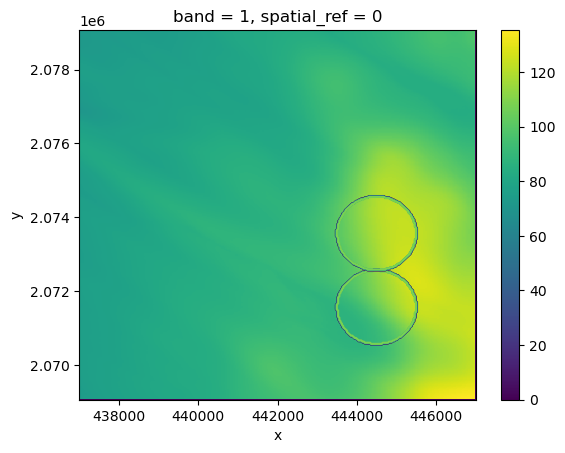

In [145]:
center_x = d.x.mean().values +2500
center_y = d.y.mean().values -2500

def m(center_x=center_x, center_y=center_y, region_size=1000):
    circular_mask = (np.abs(d.x - center_x)**2 + (np.abs(d.y - center_y)**2) < region_size**2).transpose(*d.dims)
    return xr.where(circular_mask, 1.0, 0.0)

d.plot()
m1 = m()*0.1
m2 = m(center_y = center_y + 2000)*0.1
m1.plot.contour()
m2.plot.contour()

In [146]:
def F(dem, melt):
    return fill_spill_merge(topography=dem, wtd = melt, ocean_level=ocean_value)

## Completely fill the topography. 

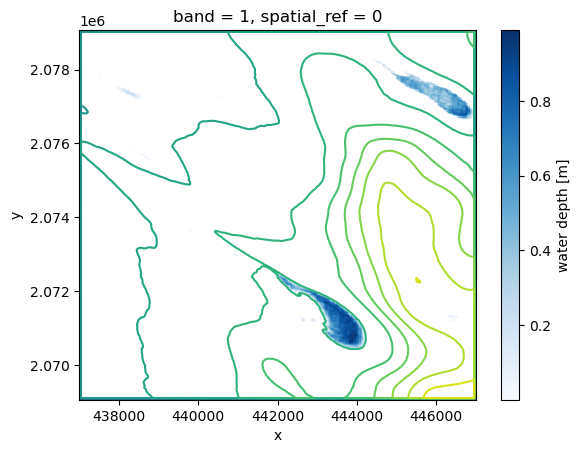

In [147]:
d.plot.contour(levels = 20)
w_full = F(d, d*0+2000)
w_full.where(w_full>0).plot(cmap = 'Blues')

## Apply m1 then m2
$$F_d(m2 + F_d(m1))$$

Text(0.5, 1.0, 'F(d, m2 + F(d, m1)')

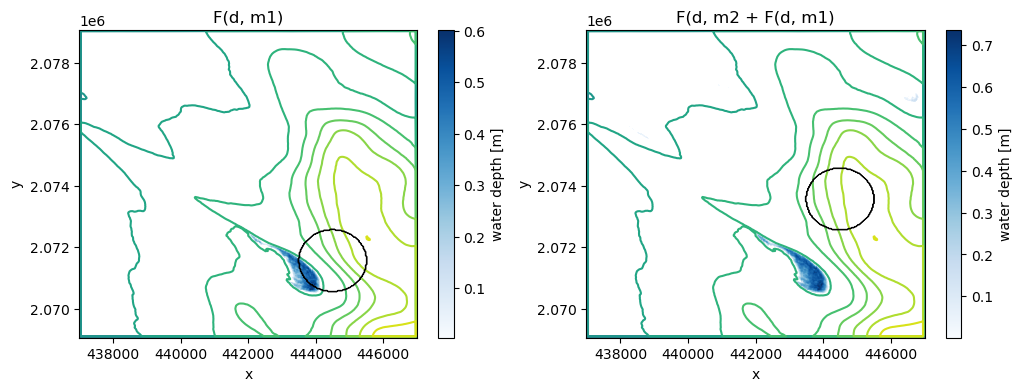

In [157]:
w1 = F(d, m1)

fig, axs = plt.subplots(1, 2, figsize = (12, 4))

d.plot.contour(ax = axs[0], levels = 20)
w1.where(w1>0).plot(ax = axs[0], cmap = 'Blues')
m1.plot.contour(ax = axs[0], colors = 'k', linewidths = 0.5)
axs[0].set_title('F(d, m1)')

d.plot.contour(ax = axs[1], levels = 20)
final_w_1 = F(d, m2 + F(d, m1))
final_w_1.where(final_w_1>0).plot(ax = axs[1], cmap = 'Blues')
m2.plot.contour(ax = axs[1], colors = 'k', linewidths = 0.5)
axs[1].set_title('F(d, m2 + F(d, m1)')


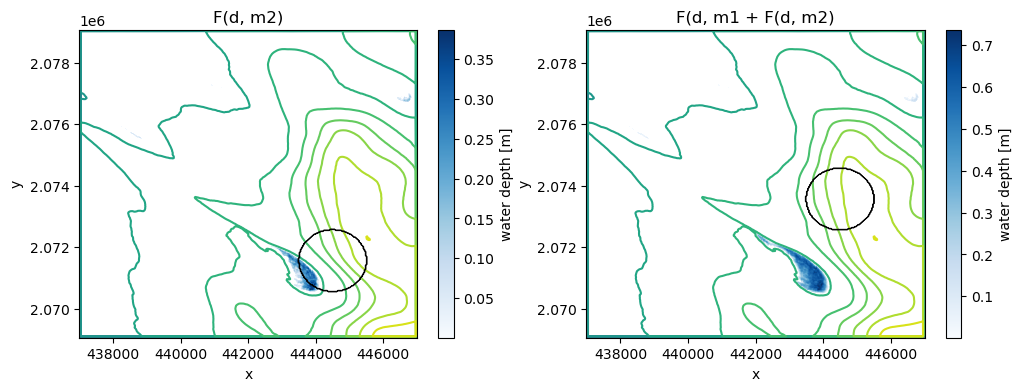

In [158]:
w1 = F(d, m2)

fig, axs = plt.subplots(1, 2, figsize = (12, 4))

d.plot.contour(ax = axs[0], levels = 20)
w1.where(w1>0).plot(ax = axs[0], cmap = 'Blues')
m1.plot.contour(ax = axs[0], colors = 'k', linewidths = 0.5)
axs[0].set_title('F(d, m2)')

d.plot.contour(ax = axs[1], levels = 20)
final_w_2 = F(d, m1 + F(d, m2))
final_w_2.where(final_w_2>0).plot(ax = axs[1], cmap = 'Blues')
m2.plot.contour(ax = axs[1], colors = 'k', linewidths = 0.5)
axs[1].set_title('F(d, m1 + F(d, m2)');


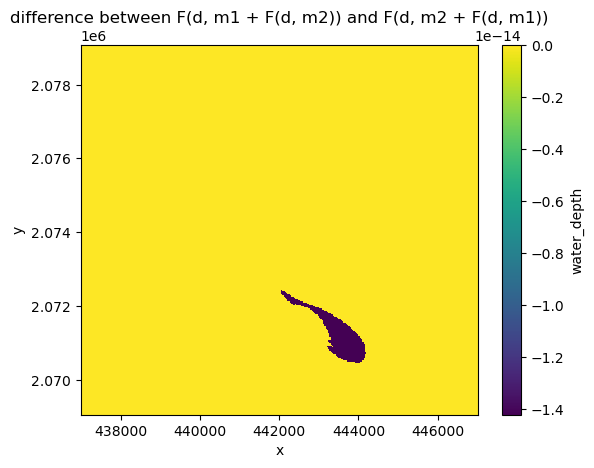

In [162]:
(final_w_2 - final_w_1).plot()
plt.title('difference between F(d, m1 + F(d, m2)) and F(d, m2 + F(d, m1))');

## Use a larger DEM

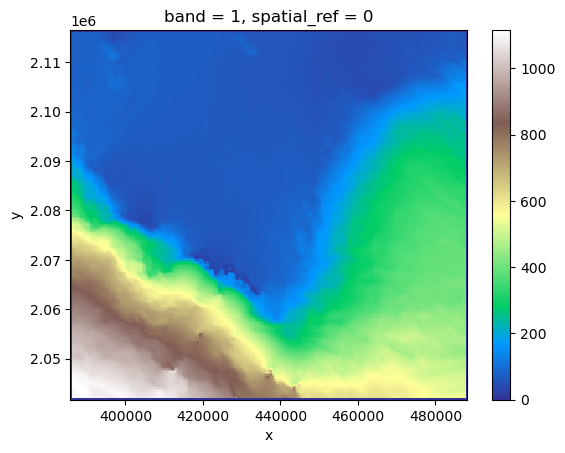

In [163]:
d = rioxarray.open_rasterio('Nivlisen_32m_REMA.tif').squeeze()
coarsen_factor = 10
d = d.coarsen(x=coarsen_factor, y=coarsen_factor, boundary='trim').mean()
ocean_value = 0.0

x1 = d.x.mean().values
y1 = d.y.mean().values

# d = d.sel(x=slice(x1, x1 + 100000), y=slice(y1, y1 - 100000))

d[0:1,:] = ocean_value 
d[-1:,:] = ocean_value
d[:,0:1] = ocean_value
d[:,-1:] = ocean_value

_, hier = fill_spill_merge(
    topography=d,
    ocean_level=ocean_value,
    return_hierarchy=True,
)
d.plot(cmap = 'terrain')

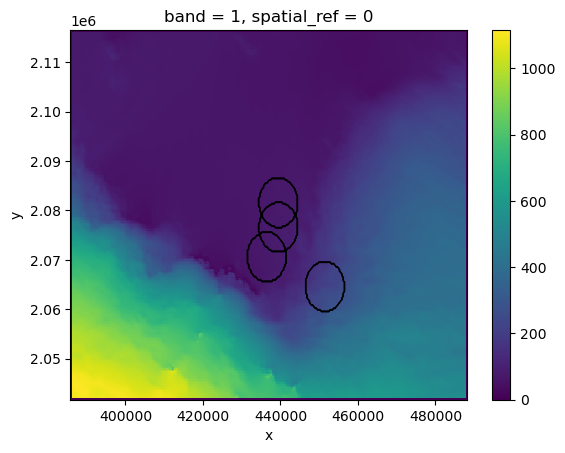

In [174]:
center_x = d.x.mean().values +2500
center_y = d.y.mean().values -2500

def m(center_x=center_x, center_y=center_y, region_size=5000):
    circular_mask = (np.abs(d.x - center_x)**2 + (np.abs(d.y - center_y)**2) < region_size**2).transpose(*d.dims)
    return xr.where(circular_mask, 1, 0.0)

d.plot()
m1 = m()*0.1
m2 = m(center_y = center_y + 5000)*0.1
m3 = m(center_y = center_y - 12000, center_x = center_x+12000)*0.1
m4 = m(center_y = center_y - 6000, center_x = center_x-3000)*0.1
m1.plot.contour(colors = 'k', linewidths = 0.5)
m2.plot.contour(colors = 'k', linewidths = 0.5)
m3.plot.contour(colors = 'k', linewidths = 0.5)
m4.plot.contour(colors = 'k', linewidths = 0.5)

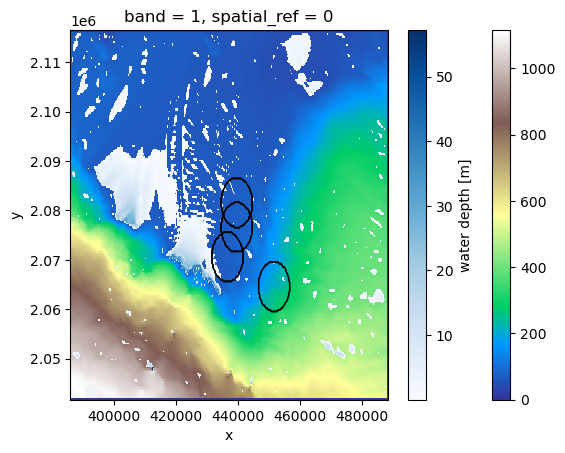

In [175]:
d.plot(cmap = 'terrain')
w_full= F(d,d*0+1000)
w_full.where(w_full!=0).plot(cmap = 'Blues')
m1.plot.contour(colors = 'k', linewidths = 0.5)
m2.plot.contour(colors = 'k', linewidths = 0.5)
m3.plot.contour(colors = 'k', linewidths = 0.5)
m4.plot.contour(colors = 'k', linewidths = 0.5)

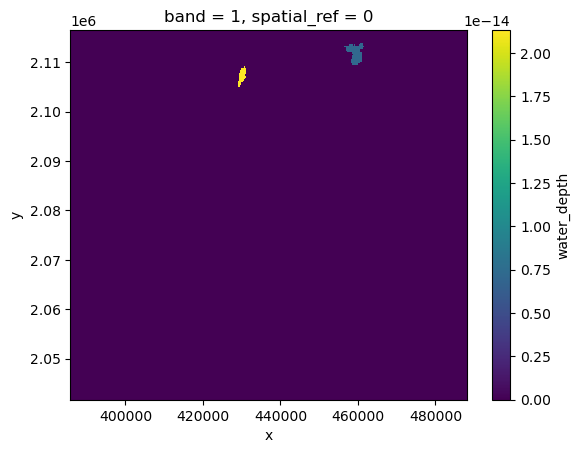

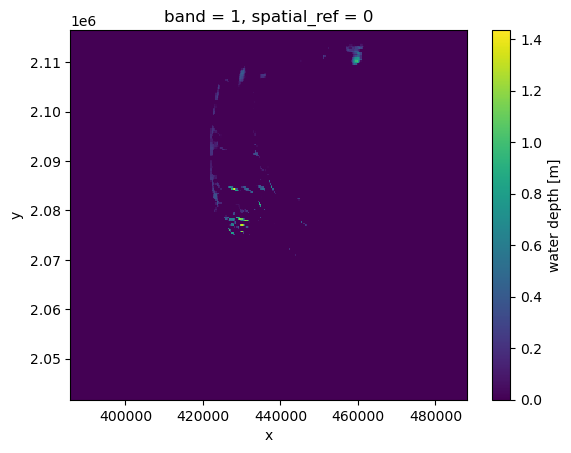

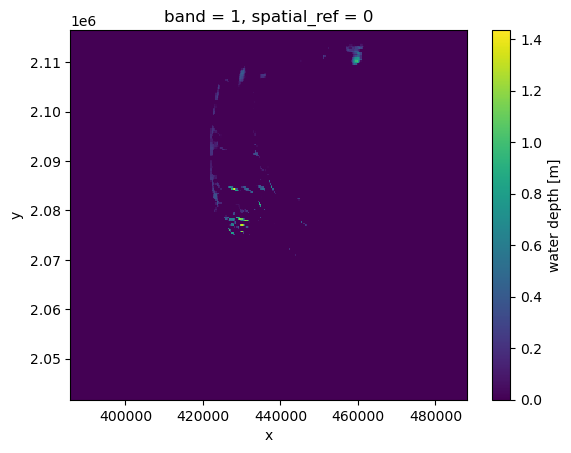

In [176]:
order1 = F(d, m2 + F(d, m1))
# order1 = order1.where(order1!=0)
order2 = F(d, m1 + F(d, m2))
order3 = F(d, m1 + m2)
# order2 = order2.where(order2!=0)

(order1-order2).plot()
# order1.plot()
plt.show()
order2.plot()
plt.show()
order3.plot()

In [177]:
def F_fold(m_list):
    result = m_list[0]
    for m in m_list[1:]:
        result = m + F(d, result)
    return F(d, result)

In [178]:
import itertools


## Iterate though all permutations of the melt field order

In [183]:
m_list = [m1, m2, m3, m4]  # however many fields you want to test

results = []
for perm in tqdm.tqdm(itertools.permutations(m_list)):
    results.append(F_fold(list(perm)))
ref = results[0]
for i, r in enumerate(results[1:], 1):
    diff = np.abs(r - ref).max().values
    print(f'permutation {i}: max diff = {diff}')

0it [00:00, ?it/s]

24it [00:08,  2.75it/s]

permutation 1: max diff = 7.105427357601002e-15
permutation 2: max diff = 7.105427357601002e-15
permutation 3: max diff = 7.105427357601002e-15
permutation 4: max diff = 7.105427357601002e-15
permutation 5: max diff = 7.105427357601002e-15
permutation 6: max diff = 2.1316282072803006e-14
permutation 7: max diff = 2.1316282072803006e-14
permutation 8: max diff = 2.1316282072803006e-14
permutation 9: max diff = 2.1316282072803006e-14
permutation 10: max diff = 2.1316282072803006e-14
permutation 11: max diff = 2.1316282072803006e-14
permutation 12: max diff = 7.105427357601002e-15
permutation 13: max diff = 7.105427357601002e-15
permutation 14: max diff = 2.1316282072803006e-14
permutation 15: max diff = 2.1316282072803006e-14
permutation 16: max diff = 7.105427357601002e-15
permutation 17: max diff = 2.1316282072803006e-14
permutation 18: max diff = 7.105427357601002e-15
permutation 19: max diff = 7.105427357601002e-15
permutation 20: max diff = 2.1316282072803006e-14
permutation 21: max

## Compare the reference from the cell above with the result of using the sum of the melt fields as input to F_d.

Text(0.5, 1.0, 'Sum of all melt fields')

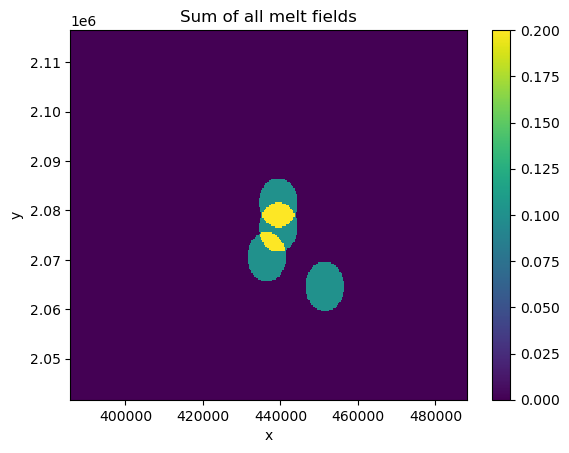

In [191]:
m_all = sum(m_list)
m_all.plot()
plt.title('Sum of all melt fields')

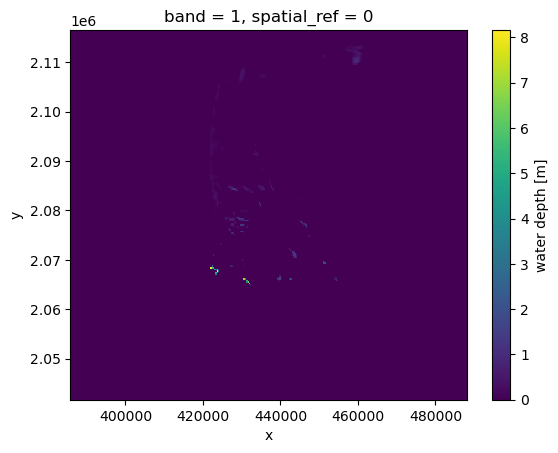

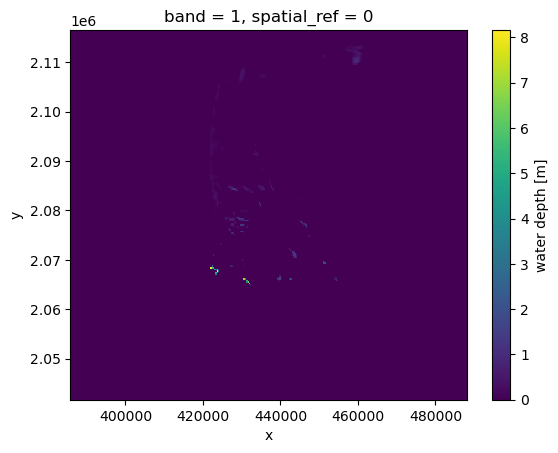

In [190]:
F(d,m_all).plot()
plt.show()
ref.plot()